# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("ai-adoption-fortune500-synthetic-dataset-2020-2025.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
df.isnull().sum()

df:        Year             Company    Industry Country Company_Type Employee_Size  \
0     2020              Amazon  E-commerce     USA         Real    Enterprise   
1     2021              Amazon  E-commerce     USA         Real    Enterprise   
2     2022              Amazon  E-commerce     USA         Real    Enterprise   
3     2023              Amazon  E-commerce     USA         Real    Enterprise   
4     2024              Amazon  E-commerce     USA         Real    Enterprise   
...    ...                 ...         ...     ...          ...           ...   
5995  2021  SyntheticCorp_0980     Telecom  Brazil    Synthetic    Enterprise   
5996  2022  SyntheticCorp_0980     Finance   India    Synthetic           SME   
5997  2023  SyntheticCorp_0980  Technology  Canada    Synthetic    Enterprise   
5998  2024  SyntheticCorp_0980   Logistics     UAE    Synthetic    Enterprise   
5999  2025  SyntheticCorp_0980  Healthcare   Japan    Synthetic           SME   

       Revenue_USD Use

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

# Seaborn Graphs to check relationship

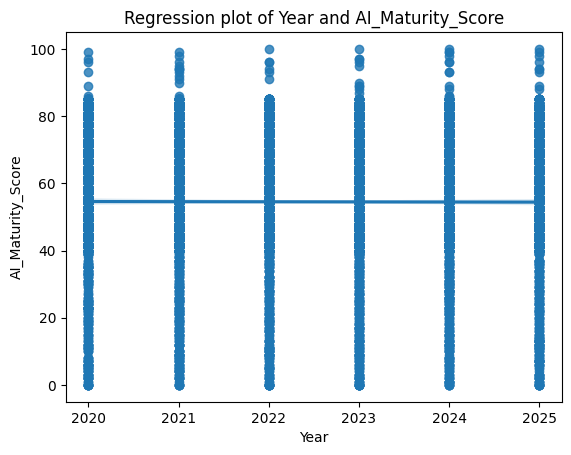

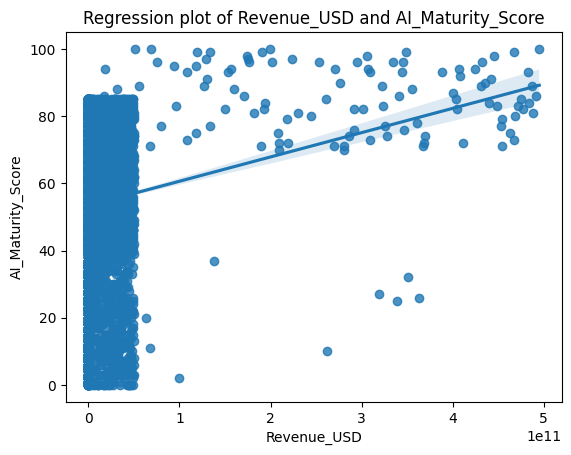

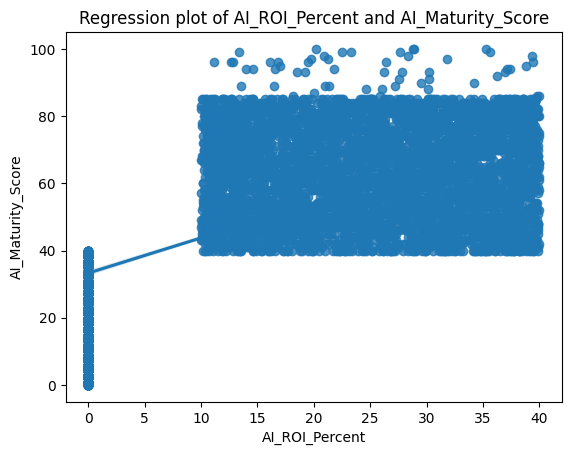

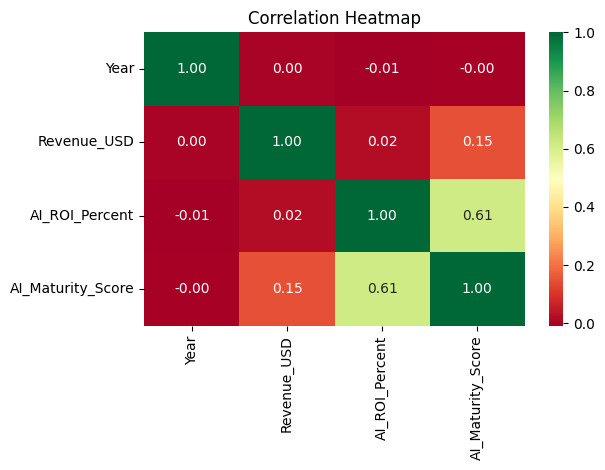

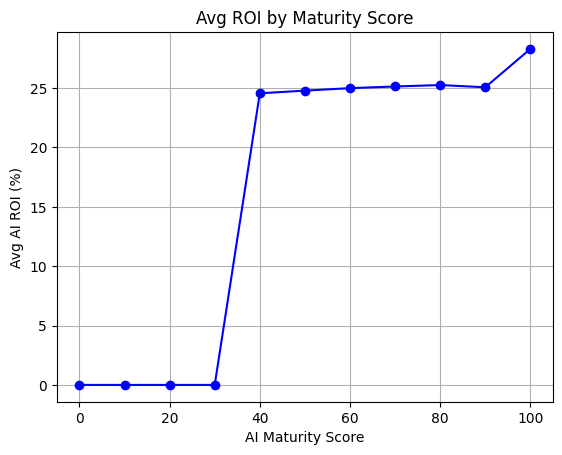

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Year', 'Revenue_USD', 'AI_ROI_Percent']   #these are the numerical columns 
for var in variables:
    plt.figure()
    sns.regplot(x=var, y='AI_Maturity_Score', data=df)
    plt.title(f"Regression plot of {var} and AI_Maturity_Score")

plt.show()


#heatmap
num_columns = ['Year', 'Revenue_USD', 'AI_ROI_Percent', 'AI_Maturity_Score']
plt.figure()
sns.heatmap(df[num_columns].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#Line plot 
df['MaturityBand'] = (df['AI_Maturity_Score'] // 10) * 10
avg = df.groupby('MaturityBand')['AI_ROI_Percent'].mean()

plt.plot(avg.index, avg.values, marker='o', color='blue')
plt.xlabel('AI Maturity Score')
plt.ylabel('Avg AI ROI (%)')
plt.title('Avg ROI by Maturity Score')
plt.grid(True)
plt.show()

# Feature Selection

In [5]:
y = df['AI_Maturity_Score']   #I have taken Ai_Maturity_Score as my target to predict it 
X = df[ ['Revenue_USD','Year', 'AI_ROI_Percent']] #these are my x features 

SEED = 24
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,  
                                                    random_state=SEED)   

print("X.shape:     \n", X.shape )   #this is use to print shape

X.shape:     
 (6000, 3)


# Linear Regression

In [6]:
#I have applied linear regression model 
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

regressor.fit(X_train, y_train)

print("regressor.intercept_......\n", regressor.intercept_)


print("regressor.coef_ " , regressor.coef_)

feature_names = X.columns
model_coefficients = regressor.coef_

coefficients_df = pd.DataFrame(data = model_coefficients, 
                              index = feature_names, 
                              columns = ['Coefficient value'])
print(coefficients_df)

y_pred = regressor.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted.....\n" , results)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

actual_minus_predicted = sum((y_test - y_pred)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted/actual_minus_actual_mean
print('R²:', r2)


#R² 0.40 Only AI_ROI has a meaningful relationship with AI_Maturity, all three models confirm this.

regressor.intercept_......
 -78.74057057064405
regressor.coef_  [6.41353148e-11 5.49930901e-02 1.03968909e+00]
                Coefficient value
Revenue_USD          6.413531e-11
Year                 5.499309e-02
AI_ROI_Percent       1.039689e+00
Actual vs Predicted.....
       Actual  Predicted
5611      80  68.811126
1973      55  61.555193
5283      79  64.628307
5634      40  42.878524
104      100  75.213290
...      ...        ...
4446      41  73.770980
1773      51  63.938512
414       55  50.833790
4042      60  69.445783
5358      79  55.803751

[1200 rows x 2 columns]
Mean absolute error: 13.34
Mean squared error: 273.54
Root mean squared error: 16.54
R²: 0.401853347917421


# Train Test Split Function

In [32]:
y = df['AI_Maturity_Score']
X = df[ ['Year','Revenue_USD', 'AI_ROI_Percent']]

SEED = 24
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=SEED)

print("X.shape:     \n", X.shape )  

X.shape:     
 (6000, 3)


# Lasso 

In [ ]:
from sklearn.linear_model import Lasso
regressor = Lasso(alpha=0.2)

regressor.fit(X_train, y_train)

print("regressor.intercept_......\n", regressor.intercept_)


print("regressor.coef_ " , regressor.coef_)

feature_names = X.columns
model_coefficients = regressor.coef_

coefficients_df = pd.DataFrame(data = model_coefficients, 
                              index = feature_names, 
                              columns = ['Coefficient value'])
print(coefficients_df)

y_pred = regressor.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted.....\n" , results)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

actual_minus_predicted = sum((y_test - y_pred)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted/actual_minus_actual_mean
print('R²:', r2)


#R² 0.38 Automatically eliminated Year and Revenue by setting their coefficients to near zero, keeping only AI_ROI.

regressor.intercept_......
 33.40262965918391
regressor.coef_  [1.04414636]
                Coefficient value
AI_ROI_Percent           1.044146
Actual vs Predicted.....
       Actual  Predicted
5611      80  69.968635
1973      55  61.396194
5283      79  65.656311
5634      40  43.979832
104      100  63.505369
...      ...        ...
4446      41  74.688177
1773      51  64.340686
414       55  51.967552
4042      60  70.438501
5358      79  56.958571

[1200 rows x 2 columns]
Mean absolute error: 13.51
Mean squared error: 281.49
Root mean squared error: 16.78
R²: 0.3844748387728434


In [ ]:
y = df['AI_Maturity_Score']
X = df[ ['Year','Revenue_USD', 'AI_ROI_Percent']]

SEED = 24
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=SEED)

print("X.shape:     \n", X.shape )  

X.shape:     
 (6000, 3)


# Ridge

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


from sklearn.linear_model import Ridge
regressor =  Ridge()

regressor.fit(X_train, y_train)

print("regressor.intercept_......\n", regressor.intercept_)


print("regressor.coef_ " , regressor.coef_)

feature_names = X.columns
model_coefficients = regressor.coef_

coefficients_df = pd.DataFrame(data = model_coefficients, 
                              index = feature_names, 
                              columns = ['Coefficient value'])
print(coefficients_df)

y_pred = regressor.predict(X_test)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted.....\n" , results)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean absolute error: {mae:.2f}')
print(f'Mean squared error: {mse:.2f}')
print(f'Root mean squared error: {rmse:.2f}')

actual_minus_predicted = sum((y_test - y_pred)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted/actual_minus_actual_mean
print('R²:', r2)


#R² 0.39 Kept all features but shrunk Revenue coefficient to nearly zero (6.5e-11), confirming it adds no predictive value.

regressor.intercept_......
 -225.93664105069618
regressor.coef_  [1.27701206e-01 6.52516138e-11 1.03784532e+00]
                Coefficient value
Year                 1.277012e-01
Revenue_USD          6.525161e-11
AI_ROI_Percent       1.037845e+00
Actual vs Predicted.....
       Actual  Predicted
1782      33  32.020444
3917      48  59.445945
221       47  44.480960
2135      12  32.658726
5224      60  49.562732
...      ...        ...
2543      52  74.257600
1773      51  63.787156
2846      59  62.193664
5799      80  66.549573
1765      58  69.790273

[1200 rows x 2 columns]
Mean absolute error: 13.58
Mean squared error: 280.03
Root mean squared error: 16.73
R²: 0.39524756835526376


c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5911615093515442e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
